Projekt algorytmu

- Opis algorytmu (cel i zastosowanie)

Celem algorytmu jest predykcja przyszłych połączeń w dynamicznych sieciach na podstawie common neihgbors. Działa on poprzez wyuczenie się co oznacza konkretna wartość common neighbors dla tego, czy połaczenie wystąpi czy nie.

- Zastosowanie:

sieci społeczne (np. rekomendacja znajomych),

analiza sieci komunikacyjnych (np. e-maile),

ogólnie rekomendacje na prostym mało wymagającym modelu

- Uzasadnienie wyboru podejścia

Zastosowano prostą regresję liniową, ponieważ:

model jest lekki, łatwy do interpretacji i szybki w treningu,

cecha CN jest dobrze znana i w miarę skuteczna, wybrałem ją ponieważ chciałem sprawdzić czy CN się do czegoś nadaje
w kontekście predykcji połączeń, widząc wyniki z listy 5.

łatwe porównywanie wyników

- Schemat działania
Wczytanie kolejnych okien czasowych (grafów).

Zbudowanie grafu treningowego z ostatnich 10 okien.

Dla wszystkich możliwych pary wierzchołków wstępującyc w grafie:

oblicz Common Neighbors (CN),

przypisz etykietę 1 (jeśli połączenie jest dla tycb wierzchołków) lub 0.

Trenuj model regresji liniowej na zrównoważonym zbiorze danych, 
biorę losując tylko część danych gdy etykieta 0.

- W testach:

oblicz CN dla krawiędzi w grafach testujących, których nie ma w zbiorze treningowym,

testuje na common neigbors dla krawiędzi w grafach testujących, których nie ma w zbiorze treningowym,

model przewiduje prawdopodobieństwo utworzenia połączenia,

Porównaj wyniki z rzeczywistymi połączeniami.

- Istniejące podobne rozwiązania

    Common Neighbors, Jaccard, Adamic-Adar — klasyczne heurystyki (Liben-Nowell & Kleinberg, 2007)
    To podejście bez uczenia maszynowego (unsupervised),
    
    modele GNN(Graph Neural Networks) (GraphSAGE, GCN) — zaawansowane, ale cięższe obliczeniowo.
    
    Łączy Graph Convolution + GAT + LSTM, by nauczyć się zmian w czasie
    
    Link Prediction in GNNs Made Easy- Deep Graph Library (DGL) Sahil Sheikh
    
    “Supervised Link Prediction Using Multiple Sources” Z. Lu, B. Savas, W. Tang, I. Dhillon; ICDM 2010 (wiele cech trochę bardziej skomp.. modele) mocno inne
    
Implementacja
- Język programowania
Python 3.9

- Biblioteki i technologie
    - NetworkX – do analizy grafów i heurystyk,

    - scikit-learn – do regresji i metryk,

    - matplotlib, seaborn – do wizualizacji i wykresów,

    - jupyter notebook

In [68]:
from networkx.algorithms.link_prediction import jaccard_coefficient
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score
import random
import igraph as ig
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
def load_graph(filepath):
    G = nx.Graph()
    with open(filepath, 'r') as f:
        for line in f:
            src, tgt, _ = line.strip().split(';')
            G.add_edge(int(src), int(tgt))
    return G

In [110]:
def merge_graphs(graph_list):
    G = nx.Graph()
    for g in graph_list:
        G.add_edges_from(g.edges())
    return G

def obliczanie_cn_dla_LK_okien(G_train):
    cn_scores = []
    for u in G_train.nodes():
        for v in G_train.nodes():
            if u < v:
                cn = len(list(nx.common_neighbors(G_train, u, v)))
                cn_scores.append(((u, v), cn))
    return cn_scores

def obliczanie_cn_dla_testu_(G_test, G_train):
    cn_scores = []
    for u in G_test.nodes():
        for v in G_test.nodes():
            if u < v:
                cn = len(list(nx.common_neighbors(G_test, u, v)))
                cn_scores.append(((u, v), cn))
    return cn_scores

def obliczanie_cn_dla_testu_niemaw_train(G_test, G_train):
    cn_scores = []
    for u in G_test.nodes():
        for v in G_test.nodes():
            if u < v and not G_train.edges(u,v):
                cn = len(list(nx.common_neighbors(G_test, u, v)))
                cn_scores.append(((u, v), cn))
    return cn_scores

def Nastepne_window_do_tworzenia_x_i_Y_wersja_1(G_train, cn_scores):
    # 3. Etykiety: 1 jeśli (u,v) pojawia się w Grafie_train, 0 w przeciwnym razie.
    edges_true = set(G_train.edges())  # jeśli chcesz z grafu treningowego
    X, y = [], []
    for (u, v), cn in cn_scores:
        X.append([cn])
        y.append(1 if (u, v) in edges_true else 0)
    return X,y

def Nastepne_window_do_tworzenia_x_i_Y_wersja_2(G_train, cn_scores):
    # 3. Etykiety: 1 jeśli (u,v) pojawia się w Grafie_train, 0 w przeciwnym razie.
    edges_true = set(G_train.edges())  # jeśli chcesz z grafu treningowego
    X, y = [], []
    for (u, v), cn in cn_scores:
        if (u, v) in edges_true:
            y.append(1)
            X.append([cn])
        else:
            if random.random() > 0.99:
                y.append(0)
                X.append([cn])
    return X,y

In [111]:
def przygotowanie_testu(graph_list, G_train):
    G_test = merge_graphs(graph_list)
    cn_test = obliczanie_cn_dla_testu_niemaw_train(G_test, G_train)
    X_test, Y_test = Nastepne_window_do_tworzenia_x_i_Y_wersja_2(G_test, cn_test)
    return G_test, X_test, Y_test
def przygotowanei_do_treningu(graph_list):
    G_train = merge_graphs(graph_list)
    cn_train = obliczanie_cn_dla_LK_okien(G_train)
    X_train, y_train = Nastepne_window_do_tworzenia_x_i_Y_wersja_2(G_train, cn_train)
    return G_train, X_train, y_train

In [5]:
grafy_train_list = [load_graph(f"C:/Users/piotr/OneDrive/Pulpit/okna_predykcja_linków/o3p3_0000{i}.txt") for i in range(1, 10)]
grafy_train_list.append(load_graph(f"C:/Users/piotr/OneDrive/Pulpit/okna_predykcja_linków/o3p3_00010.txt"))
G_test_list = [load_graph(f"C:/Users/piotr/OneDrive/Pulpit/okna_predykcja_linków/o3p3_000{i}.txt") for i in range(11, 14)]

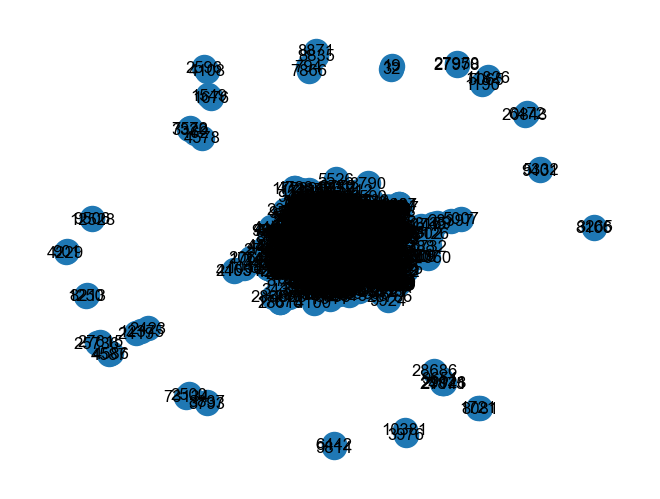

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001E188C363A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [6]:
nx.draw(G_test_list[1], with_labels=True)
plt.show()

nx.draw(grafy_train_list[1], with_labels=True)
plt.show()

In [112]:
G_train, X_train, y_train = przygotowanei_do_treningu(grafy_train_list)
G_test, X_test, Y_test = przygotowanie_testu(G_test_list, G_train)

In [113]:
clf = LogisticRegression().fit(X_train, y_train)

In [114]:
y_pred = clf.predict(X_test)

In [115]:
accuracy0 = accuracy_score(Y_test, y_pred)
print(f"Model Accuracy: {accuracy0:.2f}")
precision0 = precision_score(Y_test, y_pred)
print(f"Precision: {precision0:.2f}")
recall0 = recall_score(Y_test, y_pred)
print(f"Recall: {recall0:.2f}")
scoref10 = f1_score(Y_test, y_pred)
print(f"f1: {scoref10:.2f}")

Model Accuracy: 0.94
Precision: 0.90
Recall: 0.29
f1: 0.44


+ wariant gdy moga się powtarzać krawiędzi ze zbioru testowanego

Model Accuracy: 0.94

Precision: 0.90

Recall: 0.29

f1: 0.44

DLA p = 0.9:

Model Accuracy: 1.00

Precision: 0.70

Recall: 0.02

DLA p = 0.99:

Model Accuracy: 0.98

Precision: 0.66

Recall: 0.20


Model zgaduje cąły czas jedną klasę dla brania wszystkich próbek

In [116]:
clf2 = LogisticRegression(class_weight='balanced').fit(X_train, y_train)

In [117]:
y_pred2 = clf2.predict(X_test)

In [118]:
accuracy = accuracy_score(Y_test, y_pred2)
print(f"Model Accuracy: {accuracy:.2f}")
precision = precision_score(Y_test, y_pred2)
print(f"Precision: {precision:.2f}")
recall = recall_score(Y_test, y_pred2)
print(f"Recall: {recall:.2f}")
scoref1 = f1_score(Y_test, y_pred2)
print(f"f1: {scoref1:.2f}")

Model Accuracy: 0.94
Precision: 0.67
Recall: 0.54
f1: 0.60


+ wariant bez zabierania krawiędzi z zbioru trenigowego:

Model Accuracy: 0.94

Precision: 0.67

Recall: 0.54

f1: 0.60

Accuracy - To odsetek poprawnie sklasyfikowanych próbek w stosunku do wszystkich.
Presision - „Z tych, które zostały przewidziane jako pozytywne, ile naprawdę nimi było?”
Recall - „Z tych, które naprawdę były pozytywne, ile udało się poprawnie wykryć?”
ROC AUC	Prawdopodobieństwo dobrej klasyfikacji

dla p = 0.9:

Model Accuracy: 0.98

Precision: 0.05

Recall: 0.45

dla p = 0.99:

Model Accuracy: 0.96

Precision: 0.33

Recall: 0.45



In [ ]:
## przygotowywanie list grafóq losowych

In [119]:
tab = []
for i in range(len(grafy_train_list)):
    node = grafy_train_list[i].number_of_nodes()
    edge = grafy_train_list[i].number_of_edges()
    print("node:",node)
    print("edge:",edge)
    tab.append((node, edge))

print("\n")
tab_test = []
for i in range(len(G_test_list)):
    node = G_test_list[i].number_of_nodes()
    edge = G_test_list[i].number_of_edges()
    print("node:",node)
    print("edge:",edge)
    tab_test.append((node, edge))

node: 2607
edge: 4481
node: 2196
edge: 3239
node: 2721
edge: 4886
node: 2084
edge: 2974
node: 2901
edge: 5734
node: 2481
edge: 4041
node: 2884
edge: 6057
node: 2637
edge: 4680
node: 2323
edge: 3612
node: 2863
edge: 5519


node: 2224
edge: 3148
node: 2987
edge: 5798
node: 2319
edge: 3311


In [120]:
losowe_grafy_train_list_nx = []
losowe_grafy_train_list_ig = []
for i in range(len(grafy_train_list)):
    n = tab[i][0]  # węzłów
    m = tab[i][1]  #krawędzi
    m0 = int(m / n)
    G_ba = ig.Graph.Barabasi(n=n, m=m0, directed=False)
    G_banx = G_ba.to_networkx()
    losowe_grafy_train_list_nx.append(G_banx)
    losowe_grafy_train_list_ig.append(G_ba)

In [121]:
losowe_grafy_test_list_nx = []
losowe_grafy_test_list_ig = []
for i in range(len(G_test_list)):
    n = tab_test[i][0]  # węzłów
    m = tab_test[i][1]  #krawędzi
    m0 = int(m / n)
    G_ba = ig.Graph.Barabasi(n=n, m=m0, directed=False)
    G_banx = G_ba.to_networkx()
    losowe_grafy_test_list_nx.append(G_banx)
    losowe_grafy_test_list_ig.append(G_ba)

In [60]:
## to samo dla losowych

In [122]:
G_train_los, X_train_los, y_train_los = przygotowanei_do_treningu(losowe_grafy_train_list_nx)
G_test_los, X_test_los, Y_test_los = przygotowanie_testu(losowe_grafy_test_list_nx, G_train_los)

In [126]:
clf3 = LogisticRegression(class_weight='balanced').fit(X_train_los, y_train_los)

In [127]:
y_pred3 = clf3.predict(X_test_los)

In [128]:
accuracy1 = accuracy_score(Y_test_los, y_pred3)
print(f"Model Accuracy: {accuracy1:.2f}")
precision1 = precision_score(Y_test_los, y_pred3)
print(f"Precision: {precision1:.2f}")
recall1 = recall_score(Y_test_los, y_pred3)
print(f"Recall: {recall1:.2f}")
scoref11 = f1_score(Y_test_los, y_pred3)
print(f"f1: {scoref11:.2f}")

Model Accuracy: 0.87
Precision: 0.33
Recall: 0.06
f1: 0.09


Wyniki precyzji dla grafów losowych są takie same co w przypadku rzeczywsitej, ale recall dla rzeczywistej dużo wyższy 9 razy.

Model uczy się sensownie struktury lokalnej dla sieci rzcezywistej, w losowej sieci model nie ma czego się nauczyć. 

Model reg. dla trzeczywistej wykrywa dużo lepiej prawdziwe krawiędzie.

1 na 3 para faktycznie jest połączona jak model strzela, ale model losowy prawie zawsze strzela 0.


In [67]:
cm = confusion_matrix(Y_test_los, y_pred3)

Text(95.72222222222221, 0.5, 'Rzeczywiste')

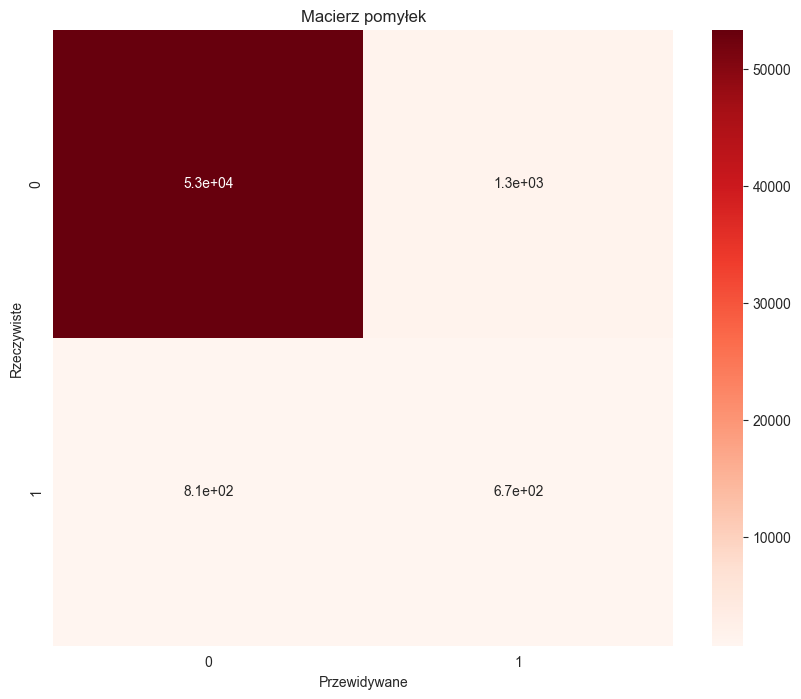

In [72]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Reds')
plt.title("Macierz pomyłek")
plt.xlabel("Przewidywane")
plt.ylabel("Rzeczywiste")

Text(95.72222222222221, 0.5, 'Rzeczywiste')

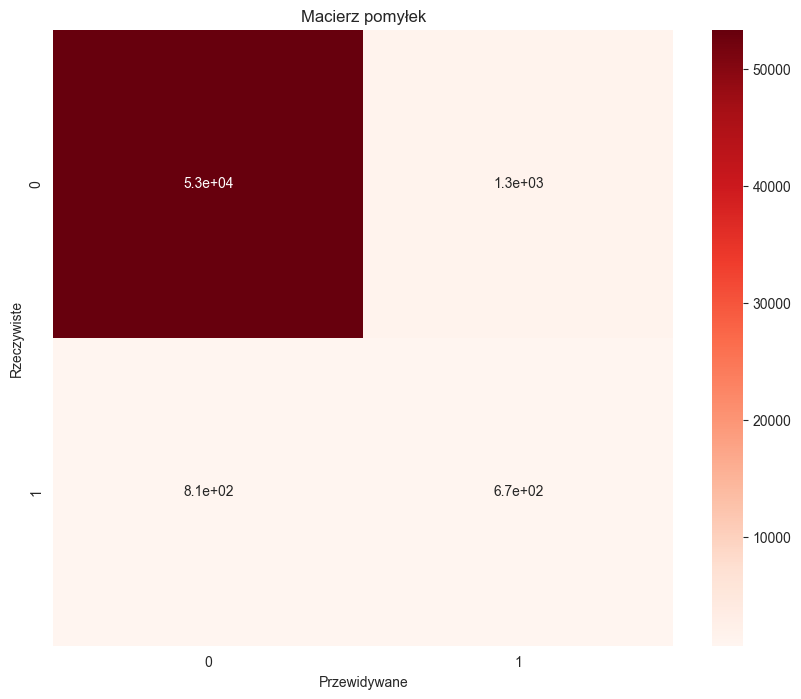

In [73]:
cm = confusion_matrix(Y_test, y_pred2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Reds')
plt.title("Macierz pomyłek")
plt.xlabel("Przewidywane")
plt.ylabel("Rzeczywiste")

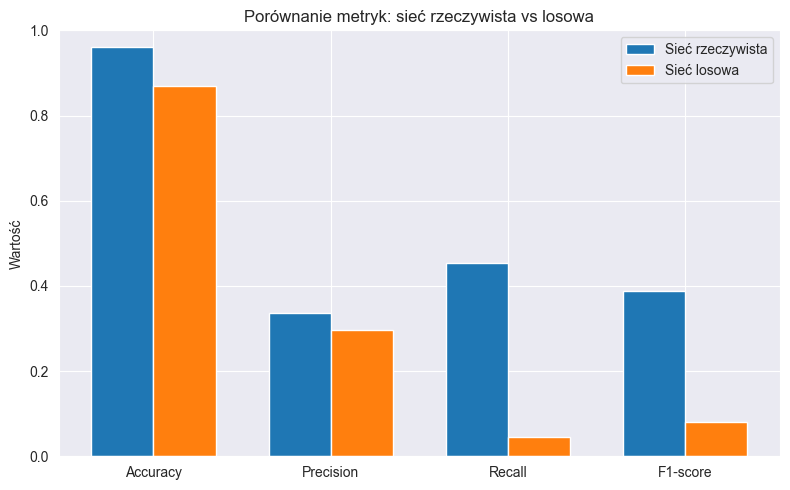

In [109]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
real_net = [accuracy, precision, recall, scoref1]
rand_net = [accuracy1, precision1, recall1, scoref11]

x = range(len(metrics))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - bar_width / 2 for i in x], real_net, width=bar_width, label='Sieć rzeczywista')
ax.bar([i + bar_width / 2 for i in x], rand_net, width=bar_width, label='Sieć losowa')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Wartość")
ax.set_title("Porównanie metryk: sieć rzeczywista vs losowa")
ax.legend()

plt.tight_layout()
plt.show()


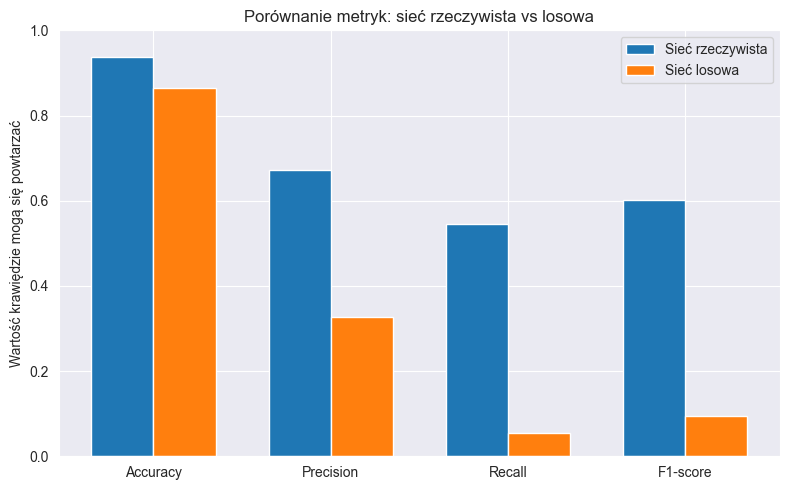

In [129]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
real_net = [accuracy, precision, recall, scoref1]
rand_net = [accuracy1, precision1, recall1, scoref11]

x = range(len(metrics))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - bar_width / 2 for i in x], real_net, width=bar_width, label='Sieć rzeczywista')
ax.bar([i + bar_width / 2 for i in x], rand_net, width=bar_width, label='Sieć losowa')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Wartość krawiędzie mogą się powtarzać")
ax.set_title("Porównanie metryk: sieć rzeczywista vs losowa")
ax.legend()

plt.tight_layout()
plt.show()

Kompletnie nic się nie zmienia dla sieci losowej gdy nie usuwamy z testu pow. się krawiędzi


- Ocena algorytmu

    - Model osiąga znacznie wyższy recall na sieci rzeczywistej, co oznacza, że rzeczywiście uczy się struktury.

    - W sieci losowej wyniki są zbliżone do zgadywania — CN nie ma tam znaczenia.

    - Pomimo niskiej precyzji (ok. 0.33), model zachowuje wartość predykcyjną, znacznie się poprawia gdy nie zabieramy krawiędzi zbioru testowego powtarzających się, bo to nie do końca jest leak.

    - Oczywiście jest on bardzo prosty i nie ma idealnych wartości metryk, ale dzieki niemu widac, 
       że common neighbors do czegoś się nadaje, ale raczej nie samodzielnie, żeby coś przewidywać

Wnioski:

- Nawet prosty model regresji liniowej + jedna cecha (CN) potrafi uchwycić lokalną strukturę w rzeczywistej sieci.

- W sieciach losowych model praktycznie nie trafia nowych połączeń, co potwierdza brak wzorców.

Warto w przyszłości:

- dodać więcej cech (np. Jaccard, AA(Czyli: jak CN, sąsiad jak bardzo jest popularny)),

- przetestować modele sekwencyjne (np. LSTM),

- RandomForestClassifier dla porównania

- zastosować kalibrację progów dla Precision@K